In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

Solved linear system with N_dof = 20402
Displacement ranges (m): ux in [-1.496e-02, 1.266e-02], uy in [0.000e+00, 1.000e-01]
Max principal stress (approx, nodewise):
sigma1 in [-1.313e+01, 1.015e+07] Pa, sigma2 in [-1.682e+05, 2.416e+06] Pa


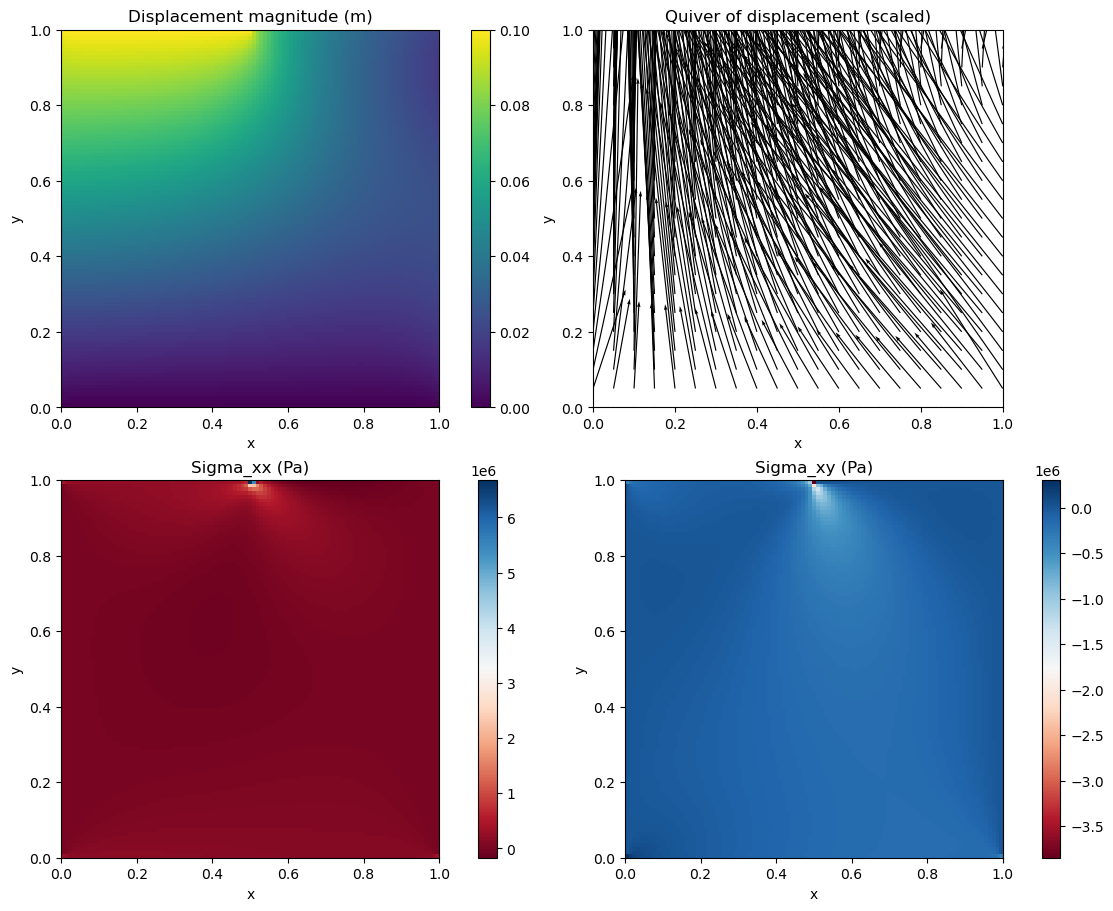

In [2]:
# Problem parameters
E = 10e6  # Pa
nu = 0.2
# Plane stress Lamé parameters
mu = E / (2 * (1 + nu))
lam = 2 * mu * nu / (1 - nu)  # equivalent to E*nu/(1-nu**2)

# Domain and grid
Lx = 1.0
Ly = 1.0
Nx = 101  # number of nodes in x
Ny = 101  # number of nodes in y
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
hx = x[1] - x[0]
hy = y[1] - y[0]
assert abs(hx - hy) < 1e-14, "This code assumes hx == hy for simplicity."
h = hx

# DOF indexing: for node (i,j), dof index:
# u (x-displacement): comp=0, v (y-displacement): comp=1
def dof(i, j, comp):
    # comp 0 or 1
    return 2 * (i + Nx * j) + comp

# Boundary condition classification
def is_dirichlet(i, j):
    # y=0 -> ux=0, uy=0
    if j == 0:
        return True
    # y=1 and x in [0,0.5] -> ux=0, uy=0.1
    if j == Ny - 1 and x[i] <= 0.5 + 1e-12:
        return True
    return False

def dirichlet_values(i, j):
    if j == 0:
        return 0.0, 0.0
    if j == Ny - 1 and x[i] <= 0.5 + 1e-12:
        return 0.0, 0.1
    raise RuntimeError("Not a Dirichlet node")

def is_boundary(i, j):
    return i == 0 or i == Nx - 1 or j == 0 or j == Ny - 1

def on_top_free(i, j):
    # top y=1 but only where x in (0.5,1]
    return (j == Ny - 1) and (x[i] > 0.5 + 1e-12)

def on_left_free(i, j):
    # x=0, excluding Dirichlet at j=0 and top-left (which is Dirichlet)
    if i == 0:
        if j == 0:
            return False
        if j == Ny - 1 and x[i] <= 0.5 + 1e-12:
            return False
        return True
    return False

def on_right_free(i, j):
    # x=1, excluding bottom (Dirichlet), include top-right (free)
    if i == Nx - 1:
        if j == 0:
            return False
        return True
    return False

# Derivatives (first-order) finite-difference stencils
# Return list of (dof_index, coefficient) representing the derivative operator acting on that component field
def d_dx_stencil(i, j, comp, scheme="center"):
    terms = []
    if scheme == "center":
        # centered: (f_{i+1,j} - f_{i-1,j}) / (2h)
        assert 1 <= i <= Nx - 2
        terms.append((dof(i + 1, j, comp), 1.0 / (2 * h)))
        terms.append((dof(i - 1, j, comp), -1.0 / (2 * h)))
    elif scheme == "left":
        # forward one-sided at left boundary: (-3f0 + 4f1 - f2)/(2h)
        assert i == 0
        terms.append((dof(i, j, comp), -3.0 / (2 * h)))
        terms.append((dof(i + 1, j, comp), 4.0 / (2 * h)))
        terms.append((dof(i + 2, j, comp), -1.0 / (2 * h)))
    elif scheme == "right":
        # backward one-sided at right boundary: (3fN - 4fN-1 + fN-2)/(2h)
        assert i == Nx - 1
        terms.append((dof(i, j, comp), 3.0 / (2 * h)))
        terms.append((dof(i - 1, j, comp), -4.0 / (2 * h)))
        terms.append((dof(i - 2, j, comp), 1.0 / (2 * h)))
    else:
        raise ValueError("Unknown scheme")
    return terms

def d_dy_stencil(i, j, comp, scheme="center"):
    terms = []
    if scheme == "center":
        assert 1 <= j <= Ny - 2
        terms.append((dof(i, j + 1, comp), 1.0 / (2 * h)))
        terms.append((dof(i, j - 1, comp), -1.0 / (2 * h)))
    elif scheme == "bottom":
        # forward one-sided at bottom boundary
        assert j == 0
        terms.append((dof(i, j, comp), -3.0 / (2 * h)))
        terms.append((dof(i, j + 1, comp), 4.0 / (2 * h)))
        terms.append((dof(i, j + 2, comp), -1.0 / (2 * h)))
    elif scheme == "top":
        # backward one-sided at top boundary
        assert j == Ny - 1
        terms.append((dof(i, j, comp), 3.0 / (2 * h)))
        terms.append((dof(i, j - 1, comp), -4.0 / (2 * h)))
        terms.append((dof(i, j - 2, comp), 1.0 / (2 * h)))
    else:
        raise ValueError("Unknown scheme")
    return terms

# Second-order derivatives for interior PDE
def d2_dxx_stencil(i, j, comp):
    # (f_{i+1} - 2 f_i + f_{i-1}) / h^2
    assert 1 <= i <= Nx - 2 and 1 <= j <= Ny - 2
    return [
        (dof(i + 1, j, comp), 1.0 / (h * h)),
        (dof(i, j, comp), -2.0 / (h * h)),
        (dof(i - 1, j, comp), 1.0 / (h * h)),
    ]

def d2_dyy_stencil(i, j, comp):
    assert 1 <= i <= Nx - 2 and 1 <= j <= Ny - 2
    return [
        (dof(i, j + 1, comp), 1.0 / (h * h)),
        (dof(i, j, comp), -2.0 / (h * h)),
        (dof(i, j - 1, comp), 1.0 / (h * h)),
    ]

def d2_dxdy_stencil(i, j, comp):
    # mixed derivative central: (f_{i+1,j+1} - f_{i+1,j-1} - f_{i-1,j+1} + f_{i-1,j-1})/(4 h^2)
    assert 1 <= i <= Nx - 2 and 1 <= j <= Ny - 2
    c = 1.0 / (4 * h * h)
    return [
        (dof(i + 1, j + 1, comp), c),
        (dof(i + 1, j - 1, comp), -c),
        (dof(i - 1, j + 1, comp), -c),
        (dof(i - 1, j - 1, comp), c),
    ]

# Assembler
N_dof = 2 * Nx * Ny
rows = []
cols = []
data = []
b = np.zeros(N_dof)

def add_to_row(row_idx, terms, factor=1.0):
    for col_idx, val in terms:
        rows.append(row_idx)
        cols.append(col_idx)
        data.append(factor * val)

# Assembly loop: for each node create two equations (one per component)
for j in range(Ny):
    for i in range(Nx):
        row_u = dof(i, j, 0)
        row_v = dof(i, j, 1)

        if is_dirichlet(i, j):
            # Strong Dirichlet
            u0, v0 = dirichlet_values(i, j)
            # ux equation
            rows.append(row_u); cols.append(row_u); data.append(1.0); b[row_u] = u0
            # uy equation
            rows.append(row_v); cols.append(row_v); data.append(1.0); b[row_v] = v0
            continue

        # Interior PDE
        if 1 <= i <= Nx - 2 and 1 <= j <= Ny - 2:
            # u-equation: (lam+2mu) u_xx + mu u_yy + (lam+mu) v_xy = 0
            add_to_row(row_u, d2_dxx_stencil(i, j, 0), factor=(lam + 2 * mu))
            add_to_row(row_u, d2_dyy_stencil(i, j, 0), factor=mu)
            add_to_row(row_u, d2_dxdy_stencil(i, j, 1), factor=(lam + mu))

            # v-equation: mu v_xx + (lam+2mu) v_yy + (lam+mu) u_xy = 0
            add_to_row(row_v, d2_dxx_stencil(i, j, 1), factor=mu)
            add_to_row(row_v, d2_dyy_stencil(i, j, 1), factor=(lam + 2 * mu))
            add_to_row(row_v, d2_dxdy_stencil(i, j, 0), factor=(lam + mu))
            # RHS zeros
            continue

        # Boundary, non-Dirichlet: traction-free
        # Choose which traction equations to apply to avoid over-constraining corners
        if on_left_free(i, j):
            # Left edge (i=0), j in [1..Ny-2] or j=Ny-1 free (not the case for left-top which is Dirichlet here)
            # t_x = sigma_xy = mu (u_y + v_x) = 0  -> assign to row_v for variety? We'll assign: row_v <- this eq
            # t_x: use u_y (centered in y), v_x (one-sided left)
            # u_y
            if 1 <= j <= Ny - 2:
                uy_terms = d_dy_stencil(i, j, 0, scheme="center")
            else:
                # top/bottom corners would have been Dirichlet here; safe default
                uy_terms = d_dy_stencil(i, j, 0, scheme="center")
            # v_x
            vx_terms = d_dx_stencil(i, j, 1, scheme="left")
            add_to_row(row_u, uy_terms, factor=mu)  # place sigma_xy=0 on row_u
            add_to_row(row_u, vx_terms, factor=mu)

            # t_y = sigma_xx = (lam+2mu) u_x + lam v_y = 0  -> place on row_v
            ux_terms = d_dx_stencil(i, j, 0, scheme="left")
            if 1 <= j <= Ny - 2:
                vy_terms = d_dy_stencil(i, j, 1, scheme="center")
            else:
                vy_terms = d_dy_stencil(i, j, 1, scheme="center")
            add_to_row(row_v, ux_terms, factor=(lam + 2 * mu))
            add_to_row(row_v, vy_terms, factor=lam)
            continue

        if on_right_free(i, j):
            # Right edge (i=Nx-1), j in [1..Ny-2], include top-right corner j=Ny-1
            # sigma_xy = mu (u_y + v_x) = 0
            # u_y (centered except at top corner), v_x (one-sided right)
            if 1 <= j <= Ny - 2:
                uy_terms = d_dy_stencil(i, j, 0, scheme="center")
            else:
                # top-right corner: one-sided tangential along y
                uy_terms = d_dy_stencil(i, j, 0, scheme="top")
            vx_terms = d_dx_stencil(i, j, 1, scheme="right")
            add_to_row(row_u, uy_terms, factor=mu)
            add_to_row(row_u, vx_terms, factor=mu)

            # sigma_xx = (lam+2mu) u_x + lam v_y = 0
            ux_terms = d_dx_stencil(i, j, 0, scheme="right")
            if 1 <= j <= Ny - 2:
                vy_terms = d_dy_stencil(i, j, 1, scheme="center")
            else:
                vy_terms = d_dy_stencil(i, j, 1, scheme="top")
            add_to_row(row_v, ux_terms, factor=(lam + 2 * mu))
            add_to_row(row_v, vy_terms, factor=lam)
            continue

        if on_top_free(i, j):
            # Top free segment: j=Ny-1, i in [1..Nx-2] with x[i]>0.5
            # sigma_xy = mu (u_y + v_x) = 0
            uy_terms = d_dy_stencil(i, j, 0, scheme="top")
            # v_x:
            if 1 <= i <= Nx - 2:
                vx_terms = d_dx_stencil(i, j, 1, scheme="center")
            elif i == 0:
                vx_terms = d_dx_stencil(i, j, 1, scheme="left")
            else:
                vx_terms = d_dx_stencil(i, j, 1, scheme="right")
            add_to_row(row_u, uy_terms, factor=mu)
            add_to_row(row_u, vx_terms, factor=mu)

            # sigma_yy = lam u_x + (lam+2mu) v_y = 0
            # u_x:
            if 1 <= i <= Nx - 2:
                ux_terms = d_dx_stencil(i, j, 0, scheme="center")
            elif i == 0:
                ux_terms = d_dx_stencil(i, j, 0, scheme="left")
            else:
                ux_terms = d_dx_stencil(i, j, 0, scheme="right")
            vy_terms = d_dy_stencil(i, j, 1, scheme="top")
            add_to_row(row_v, ux_terms, factor=lam)
            add_to_row(row_v, vy_terms, factor=(lam + 2 * mu))
            continue

        # Should not reach here: any non-Dirichlet boundary must have been handled
        raise RuntimeError(f"Unclassified boundary at (i={i}, j={j})")

# Build sparse matrix and solve
A = sp.coo_matrix((data, (rows, cols)), shape=(N_dof, N_dof)).tocsr()
sol = spla.spsolve(A, b)

# Extract displacements
Ux = np.zeros((Ny, Nx))
Uy = np.zeros((Ny, Nx))
for j in range(Ny):
    for i in range(Nx):
        Ux[j, i] = sol[dof(i, j, 0)]
        Uy[j, i] = sol[dof(i, j, 1)]

# Post-processing: strains and stresses at nodes
# First derivatives with centered in interior; one-sided at boundaries
def grad_x(F):
    G = np.zeros_like(F)
    # interior
    G[:, 1:-1] = (F[:, 2:] - F[:, :-2]) / (2 * h)
    # left boundary forward
    G[:, 0] = (-3 * F[:, 0] + 4 * F[:, 1] - F[:, 2]) / (2 * h)
    # right boundary backward
    G[:, -1] = (3 * F[:, -1] - 4 * F[:, -2] + F[:, -3]) / (2 * h)
    return G

def grad_y(F):
    G = np.zeros_like(F)
    # interior
    G[1:-1, :] = (F[2:, :] - F[:-2, :]) / (2 * h)
    # bottom forward
    G[0, :] = (-3 * F[0, :] + 4 * F[1, :] - F[2, :]) / (2 * h)
    # top backward
    G[-1, :] = (3 * F[-1, :] - 4 * F[-2, :] + F[-3, :]) / (2 * h)
    return G

exx = grad_x(Ux)                # ε_xx
eyy = grad_y(Uy)                # ε_yy
gxy = grad_y(Ux) + grad_x(Uy)   # γ_xy (engineering shear strain)

# Stresses (plane stress constitutive)
C11 = E / (1 - nu**2)
C12 = E * nu / (1 - nu**2)
C66 = mu

Sxx = C11 * exx + C12 * eyy
Syy = C12 * exx + C11 * eyy
Sxy = C66 * gxy

# Report basic info
print("Solved linear system with N_dof =", N_dof)
print("Displacement ranges (m): ux in [{:.3e}, {:.3e}], uy in [{:.3e}, {:.3e}]".format(
    Ux.min(), Ux.max(), Uy.min(), Uy.max()))
print("Max principal stress (approx, nodewise):")
# quick principal stresses at nodes (approx)
sig1 = 0.5*(Sxx+Syy) + np.sqrt( ((Sxx-Syy)*0.5)**2 + Sxy**2 )
sig2 = 0.5*(Sxx+Syy) - np.sqrt( ((Sxx-Syy)*0.5)**2 + Sxy**2 )
print("sigma1 in [{:.3e}, {:.3e}] Pa, sigma2 in [{:.3e}, {:.3e}] Pa".format(
    sig1.min(), sig1.max(), sig2.min(), sig2.max()))

# Visualization
fig, axs = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
axs[0,0].set_title("Displacement magnitude (m)")
Umag = np.sqrt(Ux**2 + Uy**2)
im0 = axs[0,0].imshow(Umag, origin='lower', extent=[0,Lx,0,Ly], cmap='viridis')
plt.colorbar(im0, ax=axs[0,0])
axs[0,0].set_xlabel('x'); axs[0,0].set_ylabel('y')

axs[0,1].set_title("Quiver of displacement (scaled)")
skip = max(1, Nx//20)
axs[0,1].quiver(x[::skip], y[::skip], Ux[::skip, ::skip], Uy[::skip, ::skip], scale=0.02)
axs[0,1].set_xlim(0, Lx); axs[0,1].set_ylim(0, Ly)
axs[0,1].set_xlabel('x'); axs[0,1].set_ylabel('y')

axs[1,0].set_title("Sigma_xx (Pa)")
im1 = axs[1,0].imshow(Sxx, origin='lower', extent=[0,Lx,0,Ly], cmap='RdBu')
plt.colorbar(im1, ax=axs[1,0])
axs[1,0].set_xlabel('x'); axs[1,0].set_ylabel('y')

axs[1,1].set_title("Sigma_xy (Pa)")
im2 = axs[1,1].imshow(Sxy, origin='lower', extent=[0,Lx,0,Ly], cmap='RdBu')
plt.colorbar(im2, ax=axs[1,1])
axs[1,1].set_xlabel('x'); axs[1,1].set_ylabel('y')

plt.show()

In [3]:
# 将所有数据保存到一个CSV文件
print("\n保存数据到CSV文件...")

# 准备数据数组
# 我们将保存：x, y, ux, uy, exx, eyy, gxy, sxx, syy, sxy
# 注意：Ux和Uy的形状是(Ny, Nx)，我们要按行主序排列
data = np.zeros((Ny * Nx, 10))

# 填充数据
index = 0
for j in range(Ny):
    for i in range(Nx):
        data[index, 0] = x[i]  # x坐标
        data[index, 1] = y[j]  # y坐标
        data[index, 2] = Ux[j, i]  # ux
        data[index, 3] = Uy[j, i]  # uy
        data[index, 4] = exx[j, i]  # exx
        data[index, 5] = eyy[j, i]  # eyy
        data[index, 6] = gxy[j, i]  # gxy (工程剪应变)
        data[index, 7] = Sxx[j, i]  # sxx
        data[index, 8] = Syy[j, i]  # syy
        data[index, 9] = Sxy[j, i]  # sxy
        index += 1

# 保存到CSV文件
filename = "results_p1-1_GPT5.csv"
np.savetxt(
    filename, 
    data, 
    delimiter=',',
    fmt='%.6e',
    header='x,y,ux,uy,exx,eyy,gxy,sxx,syy,sxy',
    comments=''
)

print(f"数据已保存到: {filename}")
print(f"数据形状: {data.shape}")
print(f"列: x, y, ux, uy, exx, eyy, gxy, sxx, syy, sxy")
print("保存完成!")


保存数据到CSV文件...
数据已保存到: results_p1-1_GPT5.csv
数据形状: (10201, 10)
列: x, y, ux, uy, exx, eyy, gxy, sxx, syy, sxy
保存完成!
